Extraindo dados do arquivo: https://raw.githubusercontent.com/gedeanekenshima/dados_reais_HATS/refs/heads/main/hats-2025-09-04.csv

Dados do arquivo real processados com sucesso!
Número total de amostras: 180000
Cadência (Intervalo entre amostras): 0.001000 s
Frequência de amostragem (fs): 1000.00 Hz
Amostras por segmento de 1s (N): 1000
Duração total do sinal: 47880.00 s


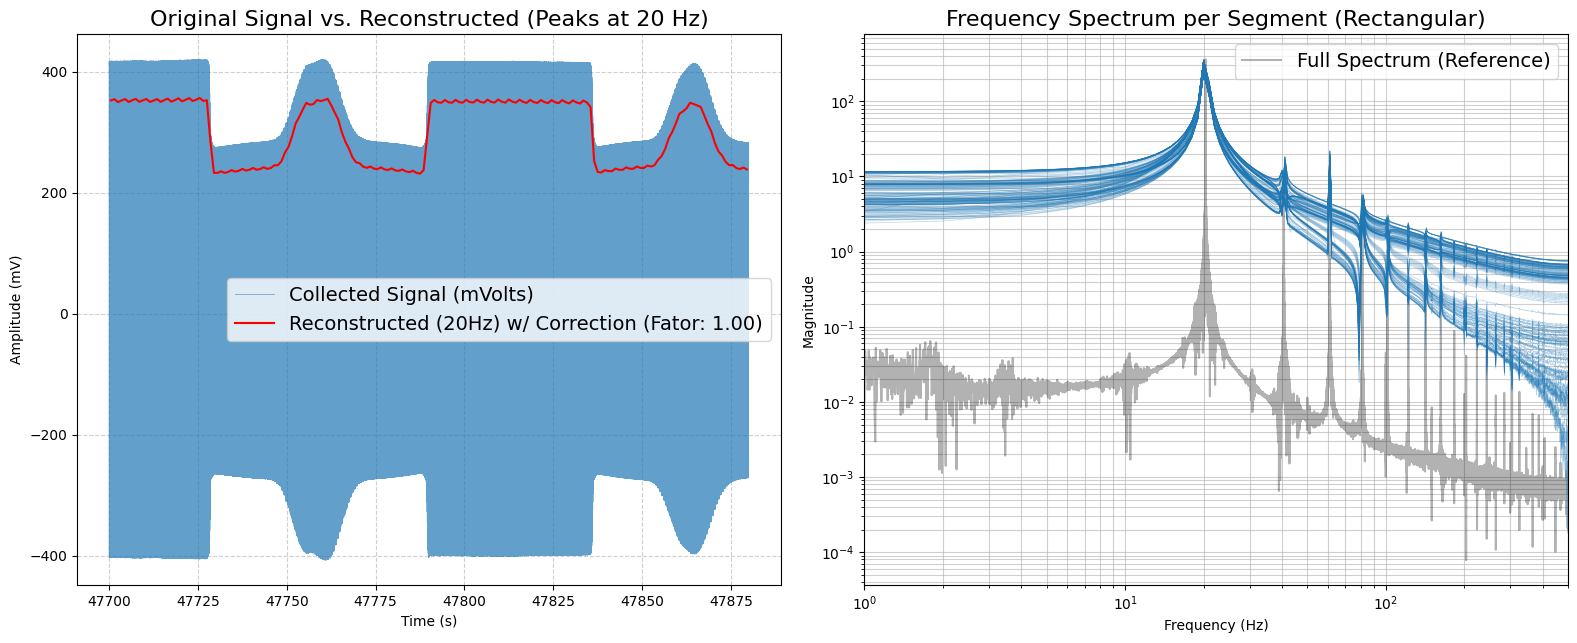

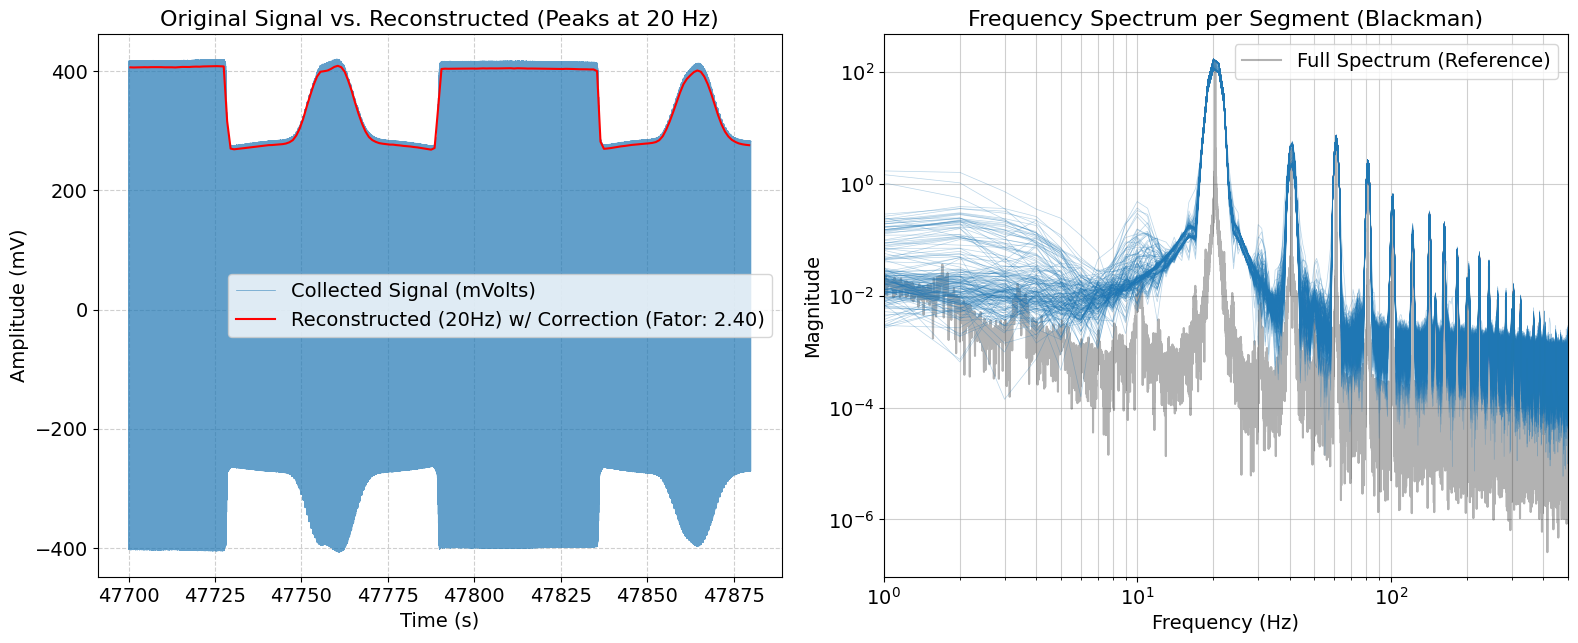

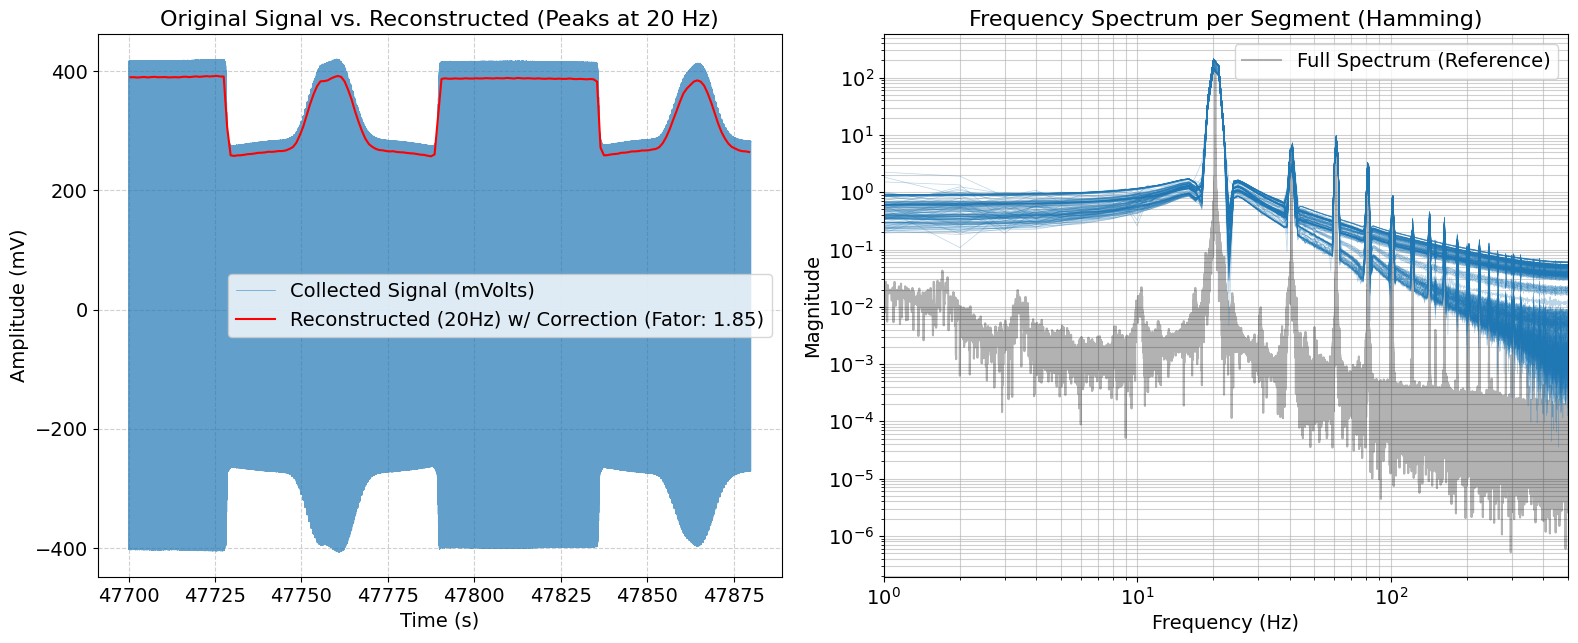

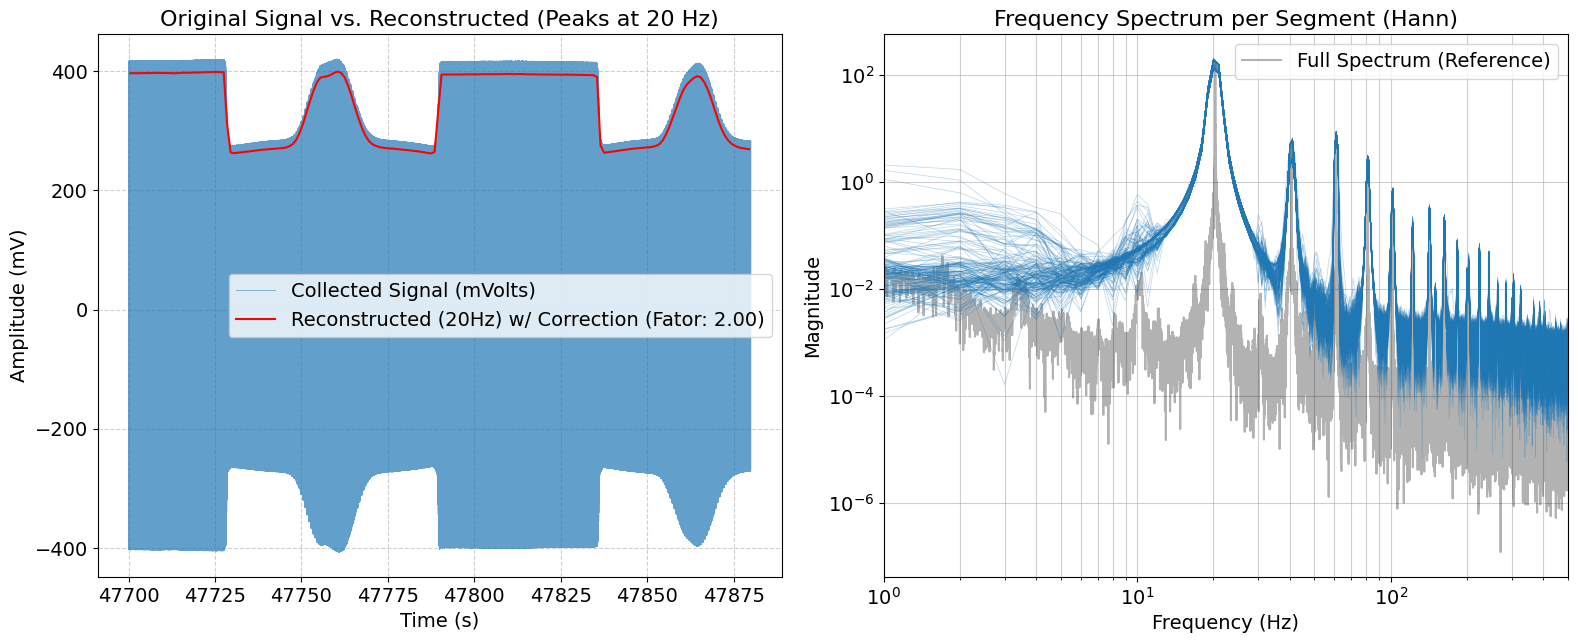

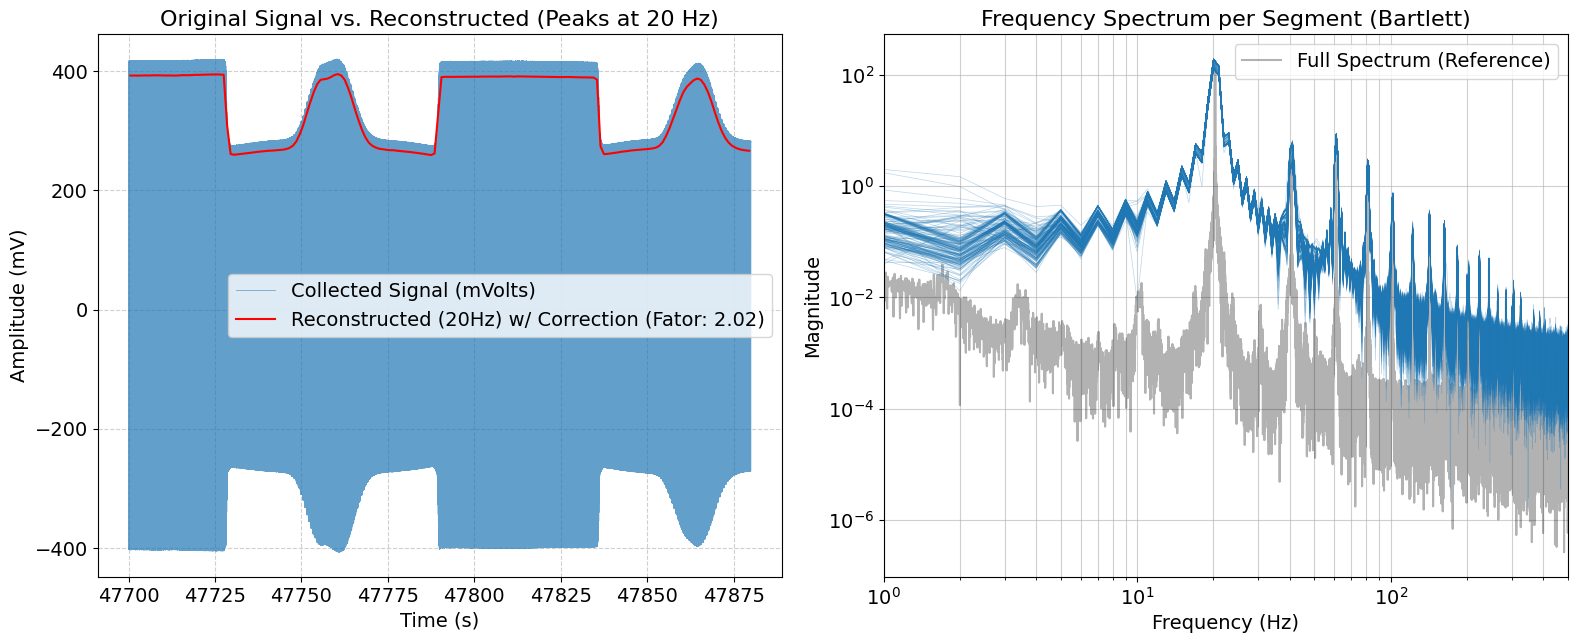

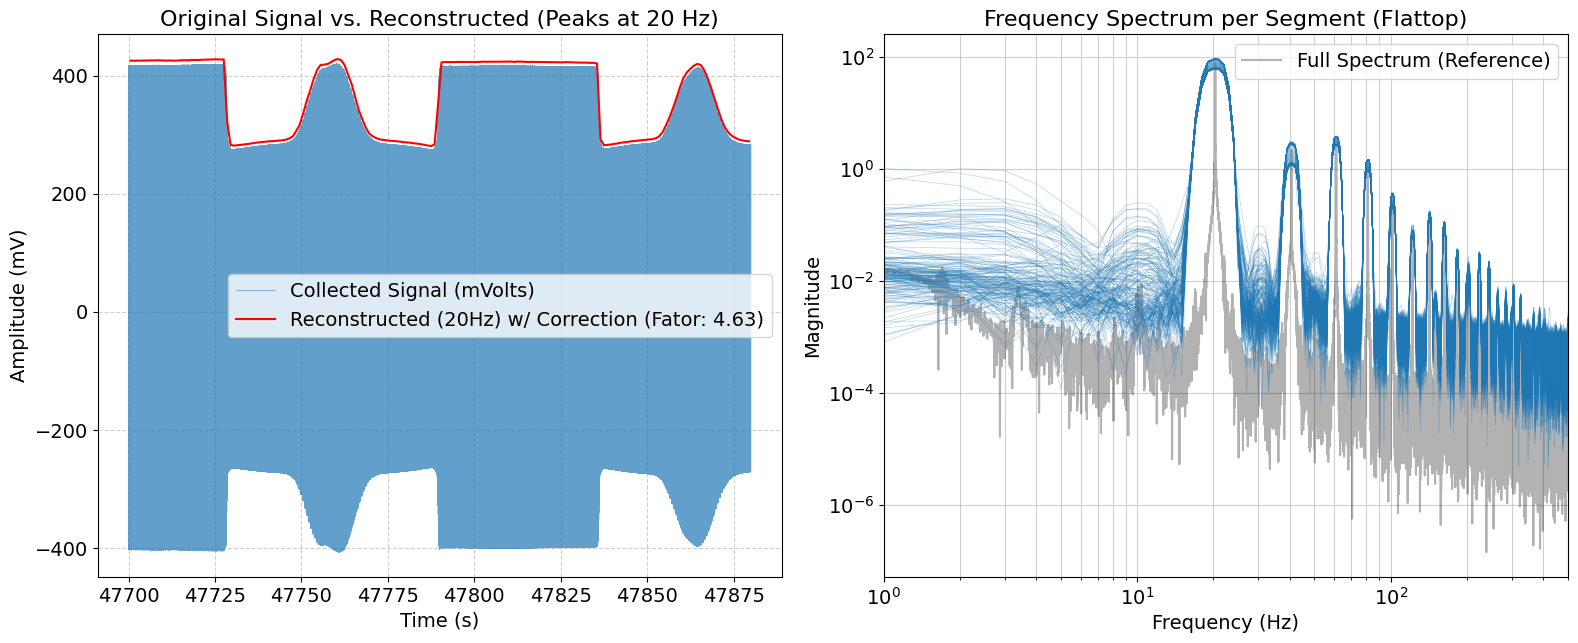

In [1]:
# Bibliotecas
import pandas as pd
import scipy.signal.windows as win
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import requests
import warnings

# Ignorar FutureWarning do matplotlib
warnings.simplefilter(action='ignore', category=FutureWarning)

# Fatores de correção de amplitude para janelas (perda por janelamento)
# Estes fatores padronizados ajudam a corrigir a atenuação de amplitude introduzida pela janela.
correction_factors = {
    'boxcar': 1.0,      # Janela retangular
    'hamming': 1.85,
    'hann': 2.0,
    'bartlett': 2.02,
    'blackman': 2.40,
    'flattop': 4.63
}

# Constantes de conversão para os dados HATS
HUSEC_TO_SECONDS_FACTOR = 0.0001  # 1 husec = 100 microssegundos = 0.0001 s

# Dicionários para internacionalização (português e inglês)
texts = {
    'pt': {
        'signal_collected': 'Sinal Coletado (mVolts)',
        'reconstructed': 'Amplitude em 20Hz (Corrigida)',
        'title1': 'Sinal Original vs. Amplitude Corrigida (Picos em 20 Hz)',
        'xlabel1': 'Tempo (s)',
        'ylabel1': 'Amplitude (mV)',
        'title2': 'Espectro de Frequência por Segmento',
        'xlabel2': 'Frequência (Hz)',
        'ylabel2': 'Magnitude',
        'full_spectrum': 'Espectro Completo (Referência)',
        'suptitle': 'Análise de Sinais - Janela'
    },
    'en': {
        'signal_collected': 'Collected Signal (mVolts)',
        'reconstructed': 'Reconstructed (20Hz) w/ Correction',
        'title1': 'Original Signal vs. Reconstructed (Peaks at 20 Hz)',
        'xlabel1': 'Time (s)',
        'ylabel1': 'Amplitude (mV)',
        'title2': 'Frequency Spectrum per Segment',
        'xlabel2': 'Frequency (Hz)',
        'ylabel2': 'Magnitude',
        'full_spectrum': 'Full Spectrum (Reference)',
        'suptitle': 'Signal Analysis - Window'
    }
}

def get_single_signal(url):
    """
    Extrai dados de um único arquivo CSV com colunas 'husec' e 'mVolts',
    converte 'husec' para segundos e calcula a frequência de amostragem (fs).
    A amplitude é mantida em mVolts.

    Args:
        url (str): A URL do arquivo CSV.

    Returns:
        tuple: Um tuple contendo o sinal (em mVolts), o vetor de tempo (em segundos)
               e a frequência de amostragem (fs).
    """
    print(f"Extraindo dados do arquivo: {url}")
    try:
        # Tenta carregar o arquivo CSV.
        data = pd.read_csv(url)

        # Tratar o caso de nomes de coluna inconsistentes (ex: minúsculos)
        col_map = {'husec': 'husec', 'mVolts': 'mVolts'}

        if not all(c in data.columns for c in col_map.keys()):
            # Tenta mapeamento flexível (ignorando case)
            data.columns = [c.lower() for c in data.columns]
            col_map = {'husec': 'husec', 'mvolts': 'mVolts'}
            if 'husec' not in data.columns or 'mvolts' not in data.columns:
                raise ValueError("O arquivo CSV não contém as colunas esperadas 'husec' e 'mVolts'.")

            # Renomeia para 'husec' e 'mVolts' para consistência interna
            data.rename(columns={data.columns[0]: 'husec', data.columns[1]: 'mVolts'}, inplace=True)

        # 1. Converter husec para segundos
        data['time_s'] = data['husec'] * HUSEC_TO_SECONDS_FACTOR
        time = data['time_s'].values

        # 2. Manter amplitude em mVolts (conversão para Volts removida)
        signal = data['mVolts'].values

        # 3. Calcular a cadência e fs
        # Calculamos a cadência média, que é o inverso de fs.
        cadence = np.mean(np.diff(time))
        fs = 1.0 / cadence

        # Filtro simples: remove valores NaN ou Inf
        valid_indices = np.isfinite(signal) & np.isfinite(time)
        signal = signal[valid_indices]
        time = time[valid_indices]

        if len(signal) == 0:
            raise ValueError("O sinal resultante está vazio após a limpeza.")

        return signal, time, fs

    except Exception as e:
        raise ValueError(f"Erro ao carregar ou processar o arquivo CSV da URL {url}: {e}")

def calculate_corrected_amplitude(signal, fs, N, window_name):
    """
    Calcula as amplitudes corrigidas em 20Hz para cada segmento de 1s de um sinal,
    aplicando uma janela específica.

    Args:
        signal (np.ndarray): O sinal de entrada (em mVolts).
        fs (float): Frequência de amostragem.
        N (int): Número de amostras por segmento (igual a fs para segmentos de 1s).
        window_name (str): O nome da janela a ser aplicada (ex: 'flattop', 'hamming').

    Returns:
        list: Uma lista de amplitudes corrigidas em 20Hz para cada segmento.
    """
    # Mapeie 'rectangular' para 'boxcar' (convenção do scipy)
    if window_name == 'rectangular':
        correction_key = 'boxcar'
    else:
        correction_key = window_name

    # Obter o fator de correção padronizado
    correction_factor = correction_factors.get(correction_key, 1.0)

    try:
        window = win.get_window(window_name, N)
    except Exception as e:
        print(f"Erro ao criar janela {window_name} com N={N}: {e}. Retornando lista vazia.")
        return []

    num_segments = int(len(signal) / N)
    magnitudes_20Hz_segments = []
    target_freq = 20.0

    for i in range(num_segments):
        start = i * N
        end = start + N
        segment = signal[start:end]

        if len(segment) < N:
            continue

        windowed_segment = segment * window
        fft_result = fft(windowed_segment)
        freqs = fftfreq(N, 1/fs)[:N//2]

        magnitudes_raw = np.abs(fft_result) / N
        idx_20Hz = np.argmin(np.abs(freqs - target_freq))
        magnitude_20Hz = magnitudes_raw[idx_20Hz] * 2.0
        amplitude_corrected = magnitude_20Hz * correction_factor
        magnitudes_20Hz_segments.append(amplitude_corrected)

    return magnitudes_20Hz_segments

def apply_and_plot_window(signal, time, window_name, plot_ax, fs, N, language='pt'):
    """
    Aplica uma janela em segmentos de 1s, calcula FFT com correção padronizada,
    encontra o pico de 20Hz e plota os resultados.

    Args:
        signal (np.ndarray): O sinal de entrada (em mVolts).
        time (np.ndarray): O vetor de tempo (em segundos).
        window_name (str): O nome da janela a ser aplicada (ex: 'flattop', 'hamming').
        plot_ax (np.ndarray): Array de subplots.
        fs (float): Frequência de amostragem.
        N (int): Número de amostras por segmento (neste caso, é igual a fs para 1s).
        language (str): Idioma para os textos dos gráficos.
    """
    # Obter textos baseados no idioma
    lang_texts = texts.get(language, texts['en'])

    # Mapeie 'rectangular' para 'boxcar' (convenção do scipy)
    if window_name == 'rectangular':
        correction_key = 'boxcar'
    else:
        correction_key = window_name

    # Obter o fator de correção padronizado
    correction_factor = correction_factors.get(correction_key, 1.0)

    try:
        window = win.get_window(window_name, N)
    except Exception as e:
        print(f"Erro ao criar janela {window_name} com N={N}: {e}. Pulando.")
        return

    # Define num_segments in this function's scope
    num_segments = int(len(signal) / N)

    # Agora, podemos usar a nova função para obter as amplitudes corrigidas
    magnitudes_20Hz_segments = calculate_corrected_amplitude(signal, fs, N, window_name)

    # --- 1. Calcular FFT do sinal completo (Referência para o segundo plot) ---
    N_full = len(signal)

    # Criamos a janela no tamanho total do sinal
    window_full = win.get_window(window_name, N_full)
    windowed_full_signal = signal * window_full
    fft_full_result = fft(windowed_full_signal)

    # Vetores de frequência e magnitude para o sinal completo
    freqs_full = fftfreq(N_full, 1/fs)[:N_full//2]
    magnitudes_full = 2.0 / N_full * np.abs(fft_full_result[0:N_full//2])

    # --- 2. Plotar os gráficos ---
    plt.rcParams.update({'font.size': 14}) # Reduzido o font size para melhor layout

    # Plot 1: Sinal original vs. amplitude de 20Hz corrigida
    # Usamos o ponto central de cada segmento para o plot de amplitude
    time_segments = time[N//2:len(signal) - N//2 + 1:N]

    plot_ax[0].plot(time, signal, lw=0.5, alpha=0.7, label=lang_texts['signal_collected'])

    # Plotamos a amplitude corrigida (ponto a ponto, no centro de cada segmento)
    plot_ax[0].plot(time_segments[:len(magnitudes_20Hz_segments)],
                    magnitudes_20Hz_segments,
                    '-',
                    markersize=4,
                    color='red',
                    label=f"{lang_texts['reconstructed']} (Fator: {correction_factor:.2f})")

    plot_ax[0].set_title(lang_texts['title1'], fontsize=16)
    plot_ax[0].set_xlabel(lang_texts['xlabel1'])
    plot_ax[0].set_ylabel(lang_texts['ylabel1'])
    plot_ax[0].grid(True, linestyle='--', alpha=0.6)
    plot_ax[0].legend(fontsize=14, loc='center right')

    # Plot 2: Espectros de frequência por segmento (comparação com o espectro completo)
    # Plotamos o espectro completo como referência
    plot_ax[1].plot(freqs_full, magnitudes_full, 'k', lw=1.5, alpha=0.3, label=lang_texts['full_spectrum'])

    # Plotamos os espectros de cada segmento (magnitudes brutas, sem correção de amplitude)
    for i in range(num_segments):
        start = i * N
        end = start + N
        segment = signal[start:end]
        if len(segment) < N:
            continue
        windowed_segment = segment * window
        fft_result = fft(windowed_segment)
        freqs = fftfreq(N, 1/fs)[:N//2]
        magnitudes = 2.0 / N * np.abs(fft_result[0:N//2]) # Magnitude de um lado

        plot_ax[1].plot(freqs, magnitudes, lw=0.5, alpha=0.3, color='#1f77b4')

    plot_ax[1].set_title(f"{lang_texts['title2']} ({window_name.capitalize()})", fontsize=16)
    plot_ax[1].set_xlabel(lang_texts['xlabel2'])
    plot_ax[1].set_ylabel(lang_texts['ylabel2'])
    plot_ax[1].set_xlim(1, fs/2)
    plot_ax[1].set_yscale('log') # Escala logarítmica para melhor visualização
    plot_ax[1].set_xscale('log') # Escala logarítmica para o eixo x (frequência)
    plot_ax[1].grid(True, which="both", ls="-", alpha=0.6)
    plot_ax[1].legend(fontsize=14, loc='upper right')

    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajustar o layout para caber o suptitle
    plt.show()

# --- Fluxo Principal do Programa ---

if __name__ == "__main__":

    # URL do arquivo CSV único (dados reais HATS)
    data_url = 'https://raw.githubusercontent.com/gedeanekenshima/dados_reais_HATS/refs/heads/main/hats-2025-09-04.csv'

    # Parâmetro de idioma: 'pt' para português (Brasil)
    language = 'en'

    try:
        # 1. Extrair sinal do único arquivo
        # O sinal agora é retornado em mVolts, conforme solicitado.
        signal, time, fs = get_single_signal(data_url)

        # 2. Calcular parâmetros de amostragem
        cadence = 1.0 / fs
        # N é o número de amostras em 1 segundo (fs amostras/s * 1 s)
        N = int(round(fs))

        print(f"\nDados do arquivo real processados com sucesso!")
        print(f"Número total de amostras: {len(signal)}")
        print(f"Cadência (Intervalo entre amostras): {cadence:.6f} s")
        print(f"Frequência de amostragem (fs): {fs:.2f} Hz")
        print(f"Amostras por segmento de 1s (N): {N}")
        print(f"Duração total do sinal: {time[-1]:.2f} s")

        # 3. Definir as janelas a serem aplicadas
        windows_to_test = ['rectangular', 'blackman', 'hamming', 'hann', 'bartlett', 'flattop']

        # 4. Aplicar e plotar para cada janela
        for window in windows_to_test:
            fig, axs = plt.subplots(1, 2, figsize=(16, 7))

            apply_and_plot_window(signal, time, window, axs, fs, N, language)

    except ValueError as e:
        print(f"Erro: {e}")
    except Exception as e:
        print(f"Ocorreu um erro inesperado: {e}")

Extraindo dados do arquivo: https://raw.githubusercontent.com/gedeanekenshima/dados_reais_HATS/refs/heads/main/hats-2025-09-04.csv


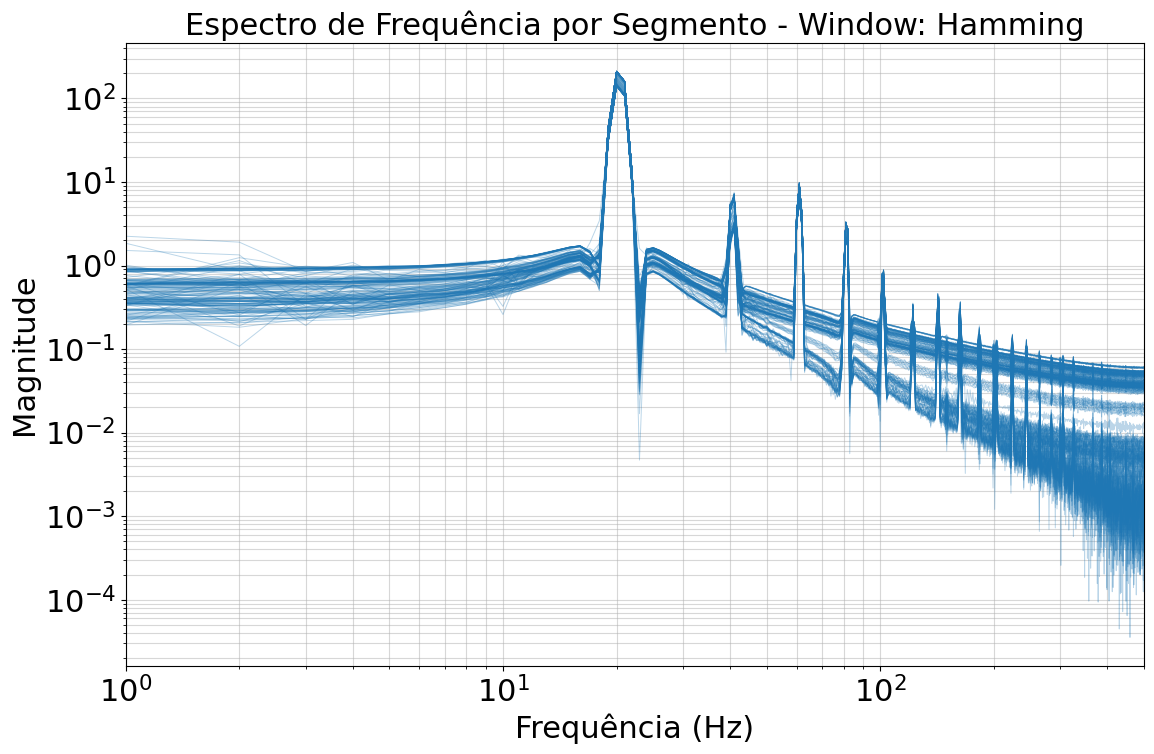

Sucesso: 180 segmentos analisados com Hamming.


In [2]:
# -- Célula para Análise Específica da Janela Hamming ---

if __name__ == "__main__":
    # Configurações iniciais
    data_url = 'https://raw.githubusercontent.com/gedeanekenshima/dados_reais_HATS/refs/heads/main/hats-2025-09-04.csv'
    language = 'pt' # 'pt' ou 'en'
    window_target = 'hamming'

    lang_texts = texts.get(language, texts['pt'])

    try:
        # 1. Extração dos dados
        signal, time, fs = get_single_signal(data_url)
        N = int(round(fs))
        num_segments = int(len(signal) / N)

        # 2. Configuração do Gráfico (Apenas 1 janela de espectro)
        plt.figure(figsize=(12, 8))
        plt.rcParams.update({'font.size': 22})

        # 3. Preparação da Janela Hamming
        window = win.get_window(window_target, N)

        # 4. Processamento e Plotagem dos Segmentos
        for i in range(num_segments):
            start = i * N
            end = start + N
            segment = signal[start:end]

            if len(segment) < N:
                continue

            # Aplicação da janela e FFT
            windowed_segment = segment * window
            fft_result = fft(windowed_segment)
            freqs = fftfreq(N, 1/fs)[:N//2]
            magnitudes = 2.0 / N * np.abs(fft_result[0:N//2]) # Magnitude monocaudal

            # Plotagem de cada segmento (azul com transparência para ver a densidade)
            plt.plot(freqs, magnitudes, lw=0.7, alpha=0.3, color='#1f77b4')

        # 5. Estilização do Gráfico
        plt.title(f"{lang_texts['title2']} - Window: {window_target.capitalize()}", fontsize=22)
        plt.xlabel(lang_texts['xlabel2'])
        plt.ylabel(lang_texts['ylabel2'])

        # Escalas logarítmicas para melhor visualização de harmônicos e ruído
        plt.xscale('log')
        plt.yscale('log')

        plt.xlim(1, fs/2) # De 1Hz até a frequência de Nyquist
        plt.grid(True, which="both", ls="-", alpha=0.5)

        # Adiciona uma linha de legenda manual para os segmentos
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='#1f77b4', lw=1, alpha=0.6)]
        #plt.legend(custom_lines, ['Segmentos de 1s (Hamming)'])

        plt.tight_layout()
        plt.show()

        print(f"Sucesso: {num_segments} segmentos analisados com Hamming.")

    except Exception as e:
        print(f"Erro ao processar: {e}")

Preparando dados...
Exibindo gráfico...


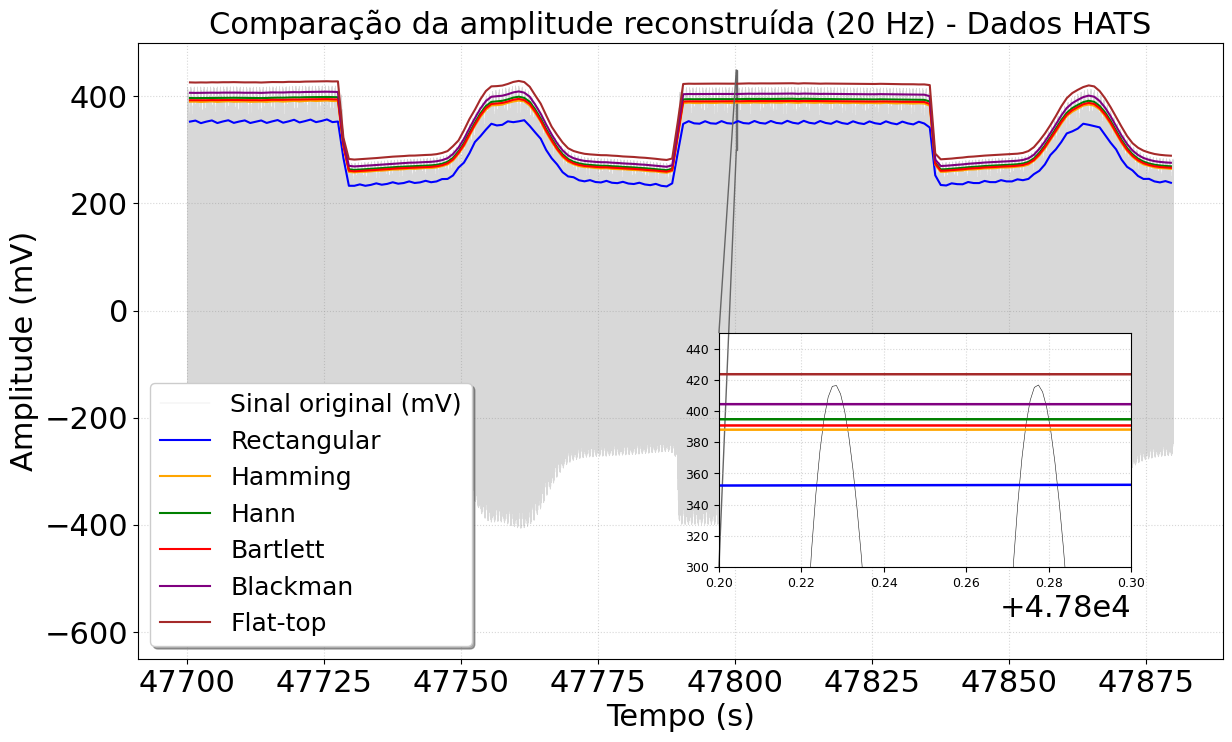

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

WINDOW_COLORS = {
    'rectangular': 'blue',
    'hamming': 'orange',
    'hann': 'green',
    'bartlett': 'red',
    'blackman': 'purple', # Lilás
    'flattop': 'brown' # Marrom
}
windows_to_test = ['rectangular', 'hamming', 'hann', 'bartlett','blackman', 'flattop']
windows_name = ['Rectangular', 'Hamming', 'Hann', 'Bartlett', 'Blackman', 'Flat-top']

# 1. PRÉ-PROCESSAMENTO (Otimizado)
print("Preparando dados...")
N_val = int(round(fs))
time_segments_val = time[N_val//2 : len(signal) - N_val//2 + 1 : N_val]

# Armazenar resultados em um dicionário para evitar cálculos repetidos
results = {win_name: calculate_corrected_amplitude(signal, fs, N_val, win_name) for win_name in windows_to_test}

# 2. CRIAÇÃO DA FIGURA
fig, ax_main = plt.subplots(figsize=(14, 8), dpi=100) # dpi fixo ajuda na renderização
plt.rcParams.update({'font.size': 22})

# --- PLOTAGEM DO SINAL DE FUNDO (OTIMIZADA) ---
# Usamos [::10] para plotar 1 a cada 10 pontos, aliviando o navegador
ax_main.plot(time[::10], signal[::10], color='gray', lw=0.3, alpha=0.3, label='Sinal original (mV)')

# --- PLOTAGEM DAS CURVAS ---
for window_name, amplitudes in results.items():
    color = WINDOW_COLORS.get(window_name, 'black')
    label_name = 'Rectangular' if window_name == 'rectangular' else window_name.capitalize()
    label_name = 'Flat-top' if window_name == 'flattop' else window_name.capitalize()
    ax_main.plot(time_segments_val[:len(amplitudes)], amplitudes, '-', lw=1.5, color=color, label=label_name)

# 3. CONFIGURAÇÃO DO ZOOM (INSET)
# Local: lower right (loc=4)
axins = inset_axes(ax_main, width="38%", height="38%", loc=4, borderpad=3)

windows_name = ['Rectangular', 'Hamming', 'Hann', 'Bartlett', 'Blackman', 'Flat-top']

# No zoom, plotamos o sinal original completo para manter a precisão
axins.plot(time, signal, color='black', lw=0.4, alpha=0.9)
for window_name, amplitudes in results.items():
    color = WINDOW_COLORS.get(window_name, 'black')
    axins.plot(time_segments_val[:len(amplitudes)], amplitudes, '-', lw=1.8, color=color)

# Limites exatos do zoom
axins.set_xlim(47800.2, 47800.3)
axins.set_ylim(300, 450)
axins.grid(True, linestyle=':', alpha=0.5)
axins.tick_params(labelsize=9)

# 4. CONECTORES E ESTÉTICA
mark_inset(ax_main, axins, loc1=2, loc2=3, fc="none", ec="0.4", lw=1)

#ax_main.set_title('Comparison of Amplitude Reconstructed (20 Hz) - HATS Data', fontsize=22)
ax_main.set_title('Comparação da amplitude reconstruída (20 Hz) - Dados HATS', fontsize=22)
ax_main.set_xlabel('Tempo (s)')
ax_main.set_ylabel('Amplitude (mV)')
ax_main.grid(True, linestyle=':', alpha=0.5)
ax_main.set_ylim(-650, 500)

# Legenda à esquerda
ax_main.legend(loc='lower left', fontsize=18, frameon=True, shadow=True)

print("Exibindo gráfico...")
plt.show()

In [4]:
# --- Análise de Precisão nos Picos ---

# Vetor de tempo no centro de cada segmento para plotagem das amplitudes
time_segments = time[N//2:len(signal) - N//2 + 1:N]

# 1. Definir a região de interesse (em torno de 47800s)
t_alvo = 47801.0  # Ajustado para o centro do patamar visível na imagem
janela_busca = 1.0 # Procurar o pico em um intervalo de 1s ao redor do alvo

# Criar máscara para o sinal original no intervalo
mask_orig = (time >= t_alvo - janela_busca) & (time <= t_alvo + janela_busca)
sinal_regiao = signal[mask_orig]
tempo_regiao = time[mask_orig]

if len(sinal_regiao) > 0:
    # Localizar o valor de pico real (máximo da senoide original)
    pico_real = np.max(sinal_regiao)
    tempo_pico_real = tempo_regiao[np.argmax(sinal_regiao)]

    # Encontrar o índice do segmento reconstruído mais próximo do tempo do pico
    idx_seg_proximo = np.argmin(np.abs(time_segments - tempo_pico_real))
    tempo_segmento = time_segments[idx_seg_proximo]

    print(f"--- Análise de Precisão no Pico (t ≈ {tempo_pico_real:.2f}s) ---")
    print(f"Valor de Pico Real (Original): {pico_real:.2f} mV\n")

    resultados_pico = []

    # 2. Coletar valores reconstruídos para cada janela no índice identificado
    for window_name in windows_to_test:
        amp_corrigidas = calculate_corrected_amplitude(signal, fs, N, window_name)

        if idx_seg_proximo < len(amp_corrigidas):
            valor_reconstruido = amp_corrigidas[idx_seg_proximo]
            distancia = valor_reconstruido - pico_real

            resultados_pico.append({
                'Janela': window_name.capitalize(),
                'Valor': valor_reconstruido,
                'Distância (Erro)': distancia
            })

    # 3. Criar DataFrame para exibição e cálculos estatísticos
    df_comparacao = pd.DataFrame(resultados_pico)

    # Calcular Estatísticas
    media_reconstruida = df_comparacao['Valor'].mean()
    desvio_padrao = df_comparacao['Valor'].std()

    # Exibir Tabela
    print(df_comparacao.to_string(index=False))
    print("-" * 50)
    print(f"Média das Amplitudes Reconstruídas: {media_reconstruida:.2f} mV")
    print(f"Desvio Padrão: {desvio_padrao:.2f} mV")
    print(f"Diferença da Média para o Pico Real: {media_reconstruida - pico_real:.2f} mV")

else:
    print("Erro: Intervalo de tempo não encontrado nos dados.")

--- Análise de Precisão no Pico (t ≈ 47801.95s) ---
Valor de Pico Real (Original): 417.03 mV

     Janela      Valor  Distância (Erro)
Rectangular 349.985074        -67.048600
    Hamming 387.834070        -29.199604
       Hann 394.873647        -22.160027
   Bartlett 390.882566        -26.151108
   Blackman 404.552804        -12.480870
    Flattop 423.830572          6.796898
--------------------------------------------------
Média das Amplitudes Reconstruídas: 391.99 mV
Desvio Padrão: 24.34 mV
Diferença da Média para o Pico Real: -25.04 mV
